In [ ]:
%run 10_MNESIS_polychronous-chains.ipynb

# overwrite some global variables locally
# datetag = '2026-04-21_wip' # WiP
figpath = Path('../figures')
# RECOMPUTE = True

datetag = '2026-04-21'
SNNtorch version 0.9.4
Variable        Type             Data/Info
------------------------------------------
LambdaLR        type             <class 'torch.optim.lr_scheduler.LambdaLR'>
OrderedDict     type             <class 'collections.OrderedDict'>
Path            type             <class 'pathlib.Path'>
RECOMPUTE       bool             False
SubplotParams   type             <class 'matplotlib.gridspec.SubplotParams'>
data_cache      PosixPath        ../cached_data
datetag         str              2026-04-21
device          device           mps
figpath         NoneType         None
flip_bits       function         <function flip_bits at 0x140cd80e0>
i_SM            int              0
nn              module           <module 'torch.nn' from '<...>es/torch/nn/__init__.py'>
np              module           <module 'numpy' from '/Us<...>kages/numpy/__init__.py'>
phi             float64          1.618033988749895
plt             module           <module 'matplotlib

## defining traveling waves patterns

In [2]:
# opt = Params(N_neuron=64**2)
opt = Params(N_neuron=42**2)
hd = HD_SNN(opt)
hd.target.shape, opt.N_neuron, opt.N_time

(torch.Size([16, 1764, 1000]), 1764, 1000)

In [3]:
import MotionClouds as mc
N_X = int(opt.N_neuron**.5)

def get_TW(angle, v=.5):
    # define Fourier domain
    mc.N_X, mc.N_Y, mc.N_frame = N_X, N_X, opt.N_time//2
    fx, fy, ft = mc.get_grids(mc.N_X, mc.N_Y, mc.N_frame)
    # define an envelope
    envelope = mc.envelope_gabor(fx, fy, ft,
        V_X=v*np.cos(angle), V_Y=v*np.sin(angle), B_V=.1,
        sf_0=.10, B_sf=.05,
        theta=0., B_theta=np.pi/8
        )
    movie = mc.random_cloud(envelope, seed=opt.seed)
    movie = mc.rectif(movie)
    movie = (2*movie - 1)
    return torch.Tensor(movie)

movie = get_TW(angle=0., v=.5)
movie.min(), movie.max()

(tensor(-1.), tensor(0.922))

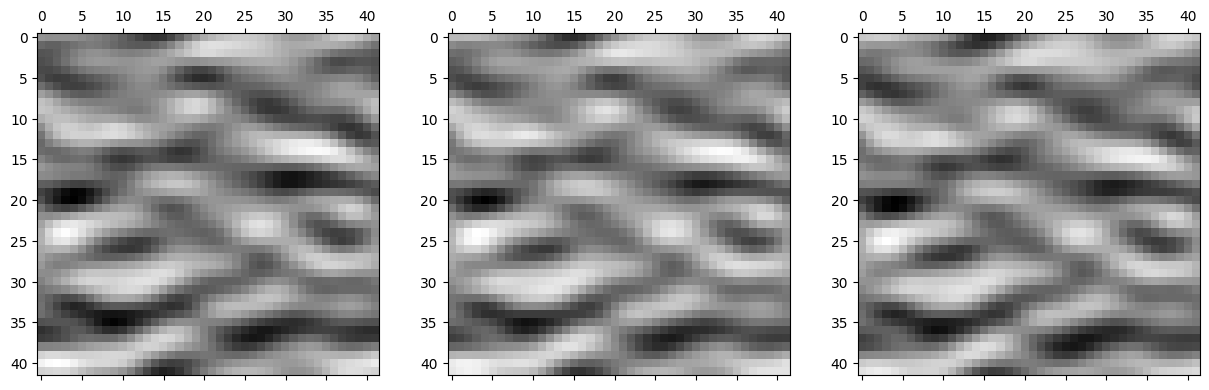

In [4]:
fig, axs = plt.subplots(1, 3, figsize=(opt.fig_width, opt.fig_width/phi))
for i_ax, ax in enumerate(axs):
    ax.matshow(movie[:, :, i_ax], cmap='gray')

In [5]:
def get_TW_spike(angle, movie_gain=10., p_A=opt.p_A):
    movie = get_TW(angle)
    A_proba = torch.sigmoid(torch.logit(torch.tensor(p_A)) + movie_gain * movie) 
    return torch.bernoulli(A_proba)

A = get_TW_spike(angle=0.)
A.shape, A.mean()

(torch.Size([42, 42, 500]), tensor(0.012))

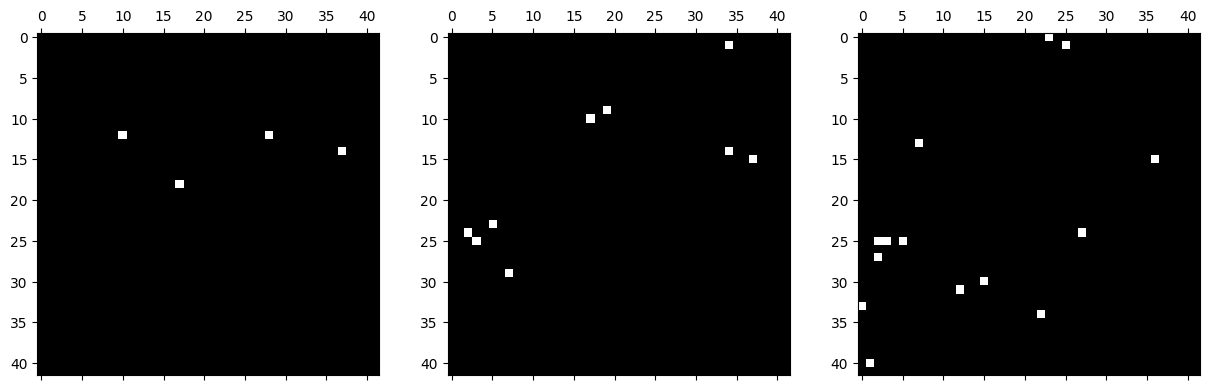

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(opt.fig_width, opt.fig_width/phi))
for i_ax, ax in enumerate(axs):
    ax.matshow(A[:, :, i_ax], cmap='gray')

In [7]:
if figpath is not None:
    import matplotlib.animation as animation

    # Create the figure and axis
    fig, ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width))

    im = ax.imshow(A[:, :, 0], cmap='gray', vmin=0, vmax=1)
    ax.axis('off')  # turn off axes

    def animate(frame):
        im.set_array(A[:, :, frame])
        ax.set_title(f"Frame {frame}")
        return [im]

    # ax.set_xlabel("X")
    # ax.set_ylabel("Y")

    anim = animation.FuncAnimation(
        fig,
        animate,
        frames=movie.shape[2],
        interval=40, # ms per frame
        blit=False,
        repeat=True
    )
    # Save as gif or mp4
    # anim.save(figpath / 'retrieval_animation.gif', writer='pillow', fps=20)
    anim.save(figpath / 'TW.mp4', writer='ffmpeg', fps=25)
    plt.close()

## learning traveling waves patterns patterns

In [8]:
# opt = Params()
# hd = HD_SNN(opt)
# hd.net.to(hd.opt.device)

# Make the target periodic
for j_SM, angle in enumerate(np.linspace(0, 2*np.pi, opt.N_SM, endpoint=False)):
    TW = get_TW_spike(angle=angle).repeat(1, 1, 2)
    hd.target[j_SM, :, :] = TW.reshape((opt.N_neuron, opt.N_time))
hd.target.shape

torch.Size([16, 1764, 1000])

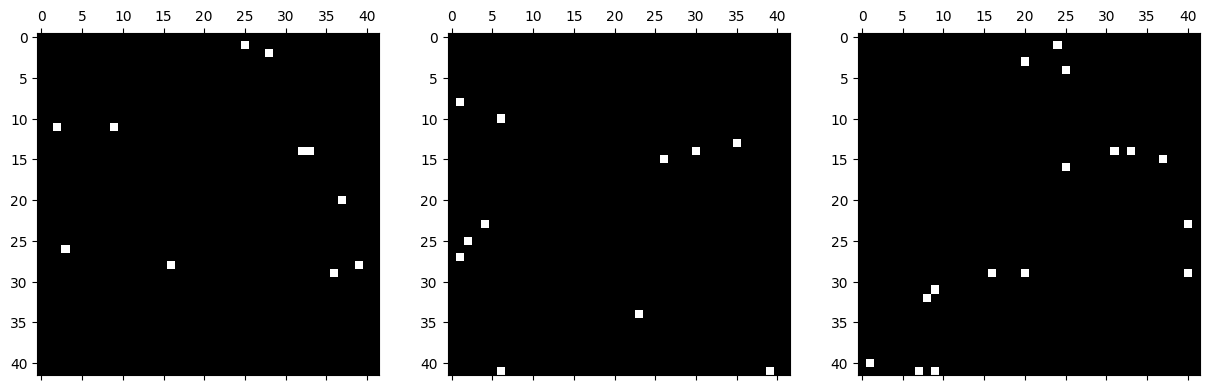

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(opt.fig_width, opt.fig_width/phi))
for i_ax, ax in enumerate(axs):
    ax.matshow(hd.target[i_SM, :,  i_ax].cpu().reshape((N_X, N_X)), cmap='gray')

In [10]:
model_filename = data_cache / f"{hd.opt.datetag}_TW.pth"
lock_filename = data_cache / model_filename.with_suffix('.lock')
if RECOMPUTE:
    model_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
    lock_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
try:
    model_state_dict = torch.load(model_filename, map_location=torch.device(hd.opt.device))
    hd.net.load_state_dict(model_state_dict)
    hd.net.eval()
    lock_filename.unlink(missing_ok=True) # in case the lock file was not unlinked
    print(f"Model weights loaded from {model_filename}") # Add a log message
except FileNotFoundError:
    if not lock_filename.exists():
        print(f"Model file not found: {model_filename}, intitializing the new model.")
        lock_filename.touch(exist_ok=True)
        ##################
        hd.update_weight()
        hd.learn_model()
        ##################
        torch.save(hd.net.state_dict(), model_filename)
        lock_filename.unlink(missing_ok=True)
    else:
        print(f"Model file is locked: {lock_filename}, passing.")

Model file not found: ../cached_data/2026-04-21_TW.pth, intitializing the new model.


/var/folders/3s/q2x8bxzj43g4rdvb2wjt67640000gq/T/ipykernel_49319/2151728497.py:90: UserWarning: The operator 'aten::linalg_svd' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:34.)
  X_pinv = torch.linalg.pinv(contexts)  # [N_neuron * num_delay, total_samples]


Train Epoch [000001/000016]	| Loss = 8.097e-04	| precision = 0.998	| recall = 1.000	| f1_score = 0.999	| 
Train Epoch [000002/000016]	| Loss = 0.000e+00	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000003/000016]	| Loss = 0.000e+00	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000004/000016]	| Loss = 0.000e+00	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000005/000016]	| Loss = 0.000e+00	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000006/000016]	| Loss = 0.000e+00	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000007/000016]	| Loss = 0.000e+00	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000008/000016]	| Loss = 0.000e+00	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000009/000016]	| Loss = 0.000e+00	| precision = 1.000	| recall = 1.000	| f1_score = 1.000	| 
Train Epoch [000010/000016]	| Loss = 0.000e+00

In [11]:
with torch.no_grad():
    target_full = torch.nn.functional.pad(hd.target, (opt.N_pretime, opt.N_pretime))
    input_spikes = hd.get_input_spikes(p_A=hd.opt.p_A, N_pretime=hd.opt.N_pretime, N_trigger_time=hd.opt.num_delay, N_time=hd.opt.N_time)
    _, _, spikes = hd.forward_pass(input_spikes)
    spikes_evoked = spikes[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(-hd.opt.N_pretime)]
    target_evoked = hd.target[:, :, hd.opt.num_delay:]

    precision, recall, f1_score = get_scores(spikes_evoked, target_evoked)
    print(f'precision = {precision:.3f}\t recall = {recall:.3f}\t f1_score = {f1_score:.3f} ')

precision = 1.000	 recall = 1.000	 f1_score = 1.000 


TypeError: unsupported operand type(s) for /: 'NoneType' and 'str'

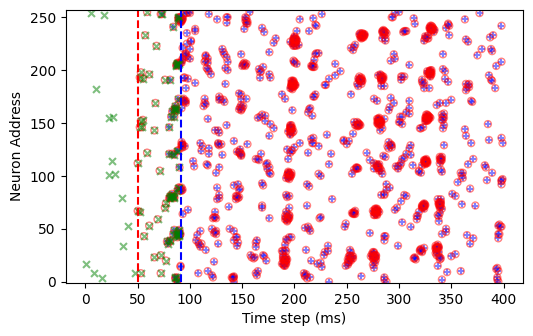

In [12]:
fig,ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width/phi))
splt.raster(spikes[i_SM, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="blue", marker='+', alpha=.5)
splt.raster(target_full[i_SM, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, facecolor='none', edgecolor='red',  marker='o', alpha=.5)
splt.raster(input_spikes[i_SM, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="green", marker='x', alpha=.5)
ax.vlines([opt.N_pretime], 0, opt.N_neuron_show, 'r', ls='--')
ax.vlines([opt.N_pretime+opt.num_delay], 0, opt.N_neuron_show, 'b', ls='--')
ax.set_xlabel("Time step (ms)")
ax.set_ylabel("Neuron Address")
ax.set_ylim(-1., opt.N_neuron_show + 1.)
if figpath is not None: printfig(fig, 'target', fig_width=opt.fig_width, fig_height=opt.fig_height)
spikes.shape, spikes[i_SM, :, :].sum().item(), hd.target[i_SM, :, :].sum().item()

In [ ]:
# hd.net.lin.bias.cpu().detach().numpy()
fig,ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width/phi))
ax.hist(hd.net.lin.weight.cpu().detach().numpy().ravel(), bins=100, density=True) # pyright: ignore[reportCallIssue, reportAttributeAccessIssue]
ax.set_yscale('log')

## a long traveling wave

In [ ]:
N_repeat = 10

with torch.no_grad():
    target_full = torch.nn.functional.pad(hd.target.repeat(1, 1, N_repeat), (opt.N_pretime, opt.N_pretime))
    input_spikes = hd.get_input_spikes(p_A=hd.opt.p_A, N_pretime=opt.N_pretime, N_trigger_time=hd.opt.num_delay, N_time=N_repeat*opt.N_time)
    _, _, spikes = hd.forward_pass(input_spikes)
    spikes_evoked = spikes[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(-hd.opt.N_pretime)]
    target_evoked = target_full[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(-hd.opt.N_pretime)]

    precision, recall, f1_score = get_scores(spikes_evoked, target_evoked)
    print(f'precision = {precision:.3f}\t recall = {recall:.3f}\t f1_score = {f1_score:.3f} ')

In [ ]:
fig,ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width/phi))
splt.raster(target_full[i_SM, :opt.N_neuron_show, :].T, ax, s=25, facecolor='none', edgecolor='red',  marker='o', alpha=.15)
splt.raster(input_spikes[i_SM, :opt.N_neuron_show, :].T, ax, s=25, c="green", marker='x', alpha=.5)
splt.raster(spikes[i_SM, :opt.N_neuron_show, :].T, ax, s=25, c="blue", marker='+', alpha=.5)
ax.vlines([opt.N_pretime], 0, opt.N_neuron_show, 'r', ls='--')
ax.vlines([opt.N_pretime+opt.num_delay], 0, opt.N_neuron_show, 'b', ls='--')
ax.set_xlabel("Time step (ms)")
ax.set_ylabel("Neuron Address")
ax.set_ylim(-1., opt.N_neuron_show + 1.)
spikes.shape, spikes[i_SM, :, :].sum().item(), hd.target[i_SM, :, :].sum().item()

## a long traveling wave

In [ ]:
with torch.no_grad():
    N_iti_time = 10 #opt.N_pretime # * 4
    # N_stop = 10 #opt.num_delay
    target_full = torch.nn.functional.pad(hd.target, (N_iti_time, N_iti_time))
    target_full = target_full.permute((1, 0, 2)).reshape((opt.N_neuron, opt.N_SM*(opt.N_time+2*N_iti_time)))

    mask = torch.ones((opt.N_SM, opt.N_neuron, opt.N_time), device=target_full.device)
    mask[:, :, opt.num_delay:] *= 0
    # mask[:, :, opt.num_delay:(-2*opt.num_delay)] *= 0
    mask = torch.nn.functional.pad(mask, (N_iti_time, N_iti_time))
    mask = mask.permute((1, 0, 2)).reshape((opt.N_neuron, opt.N_SM*(opt.N_time+2*N_iti_time)))
    

    # shunt = torch.ones((opt.N_SM, opt.N_neuron, opt.N_time), device=target_full.device)
    p_shunt = opt.p_A
    p_shunt = .115
    p_shunt = .15
    shunt = torch.bernoulli(p_shunt * torch.ones((opt.N_SM, opt.N_neuron, opt.N_time), device=target_full.device))
    shunt[:, :, :(-opt.num_delay)] *= 0
    shunt = torch.nn.functional.pad(shunt, (N_iti_time, N_iti_time))
    shunt = shunt.permute((1, 0, 2)).reshape((opt.N_neuron, opt.N_SM*(opt.N_time+2*N_iti_time)))
    
    ##################        
    input_spikes = (target_full * mask + shunt).unsqueeze(0)
    # input_spikes = flip_bits(input_spikes, p_flip)
    _, _, spikes = hd.forward_pass(input_spikes.to(opt.device))
    spikes = spikes.squeeze(0)
    ##################        

In [ ]:
# hd.target.shape, hd.target[:, :-N_stop].shape, spikes.shape, target_full.shape, opt.N_SM*(opt.N_time-N_stop+2*N_iti_time)

In [ ]:
fig,ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width/phi))
splt.raster(target_full[ :opt.N_neuron_show, :].T, ax, s=25, facecolor='none', edgecolor='red',  marker='o', alpha=.15)
# splt.raster(input_spikes[:opt.N_neuron_show, :].T, ax, s=25, c="green", marker='x', alpha=.5)
splt.raster(spikes[:opt.N_neuron_show, :].T, ax, s=25, c="blue", marker='+', alpha=.1)
ax.vlines([opt.N_pretime], 0, opt.N_neuron_show, 'r', ls='--')
ax.vlines([opt.N_pretime+opt.num_delay], 0, opt.N_neuron_show, 'b', ls='--')
ax.set_xlabel("Time step (ms)")
ax.set_ylabel("Neuron Address")
ax.set_ylim(-1., opt.N_neuron_show + 1.)
spikes.shape, target_full.shape

In [ ]:
fig,ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width/phi))
ax.plot(spikes.mean(dim=0).cpu())
ax.set_xlabel("Time step (ms)")
ax.set_ylabel("Firing rate (Hz)")
spikes.shape, target_full.shape

TODO : the signal is periodic and never ends - how do I stop a memory ?

In [ ]:
if figpath is not None:
    import matplotlib.animation as animation

    # Create the figure and axis
    fig, ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width))

    frame = 0
    colored_spikes = torch.zeros((N_X, N_X, 3))
    colored_spikes[:, :, 0] = spikes[:, frame].reshape((N_X, N_X))
    colored_spikes[:, :, 1] = input_spikes[0, :, frame].reshape((N_X, N_X))

    im = ax.imshow(colored_spikes, vmin=0, vmax=1)
    ax.axis('off')  # turn off axes

    def animate(frame):
        colored_spikes = torch.zeros((N_X, N_X, 3))
        colored_spikes[:, :, 0] = spikes[:, frame].reshape((N_X, N_X))
        colored_spikes[:, :, 1] = input_spikes[0, :, frame].reshape((N_X, N_X))
        im.set_array(colored_spikes)
        ax.set_title(f"Frame {frame}")
        return [im]

    # ax.set_xlabel("X")
    # ax.set_ylabel("Y")

    anim = animation.FuncAnimation(
        fig,
        animate,
        frames=movie.shape[2],
        interval=40, # ms per frame
        blit=False,
        repeat=True
    )
    # Save as gif or mp4
    # anim.save(figpath / 'retrieval_animation.gif', writer='pillow', fps=20)
    anim.save(figpath / 'TW_spikes.mp4', writer='ffmpeg', fps=25)
    plt.close()